In [1]:
#библиотеки для работы с данными
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#библиотеки визуализации
import seaborn as sns
import matplotlib.pyplot as plt

import math
from datetime import datetime
from itertools import combinations
from scipy import stats

#библиотеки ML. 
# модели
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

#преобразования, метрики
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder,RobustScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve,precision_score,recall_score,f1_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


#оптимизация гиперпараметров
from skopt import BayesSearchCV
from skopt.space import Real,Categorical,Integer
import optuna

import warnings
warnings.filterwarnings('ignore')

**Задача** - предсказать заключит ли клиент договор на вклад или нет. То есть бинарная классификация.

**Метрика** согласно заданию - ROC_AUC. 

**Данные** - синтетические основанные на оригинальном банковском датасете. Для чистоты, оригинальные данные в обучении использовать не будем.

In [2]:
#Загружаем датасеты. Тренировочный и тестовый.
df_train = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
df_test  = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")

In [3]:
#посмотрим на случайные 5 наблюдений
df_train.sample(5)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
424070,424070,31,student,single,unknown,no,3511,no,no,cellular,2,jul,667,1,-1,0,unknown,1
327319,327319,35,blue-collar,married,secondary,no,-5,yes,no,cellular,28,jul,63,3,-1,0,unknown,0
34417,34417,31,management,single,tertiary,no,4533,no,no,cellular,20,aug,623,1,-1,0,unknown,0
533972,533972,47,admin.,married,secondary,no,565,yes,no,cellular,7,may,127,1,-1,0,unknown,0
463339,463339,30,management,married,tertiary,no,4,no,no,cellular,12,aug,122,3,-1,0,unknown,0


In [4]:
#Посмотрим общую информацию по датасету.
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


Видим 17 признаков и 1 метку таргета. Добавим описание признаков для удобства.

**Описание**

**id**: Идентификационный номер 

**age**: Возраст клиента (числовое значение)

**job**: Работа (категориальный)

**marital**: Семейное положение (категориальный)

**education**: Уровень образования (категориальный)

**default**: Есть ли просроченный кредит? (категориальный)

**balance**: Среднегодовой баланс в евро (числовое значение)

**housing**: Есть ли жилищный кредит? (категориальный)

**loan**: Есть ли личный кредит? (категориальный)

**contact**: Тип связи с клиентом (категориальный)

**day**: День последнего контакта с клиентом (числовое значение)

**month**: Месяц последнего контакта с клиентом  (категориальный)

**duration**: Продолжительность последнего контакта в секундах (числовое значение)

**campaign**: Количество контактов с клиентом в рамках текущей кампании (числовое значение)

**pdays**: Количество дней, прошедших с последнего контакта в предыдущей кампании (числовое значение)

**previous**: Количество контактов до текущей кампании (числовое значение)

**poutcome**: Результат предыдущей маркетинговой кампании (категориальный)

**y**: Целевая переменная, подписался ли клиент на срочный депозит (бинарный)

In [5]:
#посмотрим на статистику числовых данных
df_train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


**Вывод**

1. Все признаки имеют полные данные, так как count равен 750000 для каждого столбца.
2. Баланс (balance) в среднем около 1204 евро, но большие колебания: максимум до 99717, а минимум до -8019 (возможно, отрицательный баланс).
3. Некоторые признаки, как pdays и previous, имеют отрицательные значения (-1) — это может означать отсутствие предыдущих контактов или другой специальный код.
4. Целевой признак y (договор на депозит) имеет среднее 0.12065, что говорит о том, что примерно 12% клиентов подписались.

In [6]:
#выведем уникальные значения категориальных переменных
for col in df_train.select_dtypes(exclude = ['number']).columns:
    unique_values = df_train[col].unique()
    print(f'Уникальные значения для признака {col} : {unique_values}')

Уникальные значения для признака job : ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
Уникальные значения для признака marital : ['married' 'single' 'divorced']
Уникальные значения для признака education : ['secondary' 'primary' 'tertiary' 'unknown']
Уникальные значения для признака default : ['no' 'yes']
Уникальные значения для признака housing : ['no' 'yes']
Уникальные значения для признака loan : ['no' 'yes']
Уникальные значения для признака contact : ['cellular' 'unknown' 'telephone']
Уникальные значения для признака month : ['aug' 'jun' 'may' 'feb' 'apr' 'nov' 'jul' 'jan' 'oct' 'mar' 'sep' 'dec']
Уникальные значения для признака poutcome : ['unknown' 'other' 'failure' 'success']


In [7]:
#есть ли пропуски
df_train.isna().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
#Пропусков в формате NaN нет, но в перечне значений категориальных признаков было "Uncknown" 
for col in df_train.columns:
    if df_train[col].dtype == 'object':
        print(f'Доля неизвестных в {col} : {round(df_train[col].isin(["unknown"]).sum()/df_train.shape[0]*100,2)}%')

Доля неизвестных в job : 0.39%
Доля неизвестных в marital : 0.0%
Доля неизвестных в education : 2.84%
Доля неизвестных в default : 0.0%
Доля неизвестных в housing : 0.0%
Доля неизвестных в loan : 0.0%
Доля неизвестных в contact : 30.88%
Доля неизвестных в month : 0.0%
Доля неизвестных в poutcome : 89.66%


Видим что в признаках contact и poutcome много неизвестных. 

При доле неизвестных почти 90% признак poutcome неинформативен.

In [9]:
df_train.drop('poutcome' , axis = 1, inplace = True)
df_test.drop('poutcome' , axis = 1, inplace = True)

In [10]:
#проверим на дубликаты
num_duplicates = df_train.duplicated().sum()
print(f'Количество дубликатов: {num_duplicates}')

Количество дубликатов: 0


Построим графики распределений

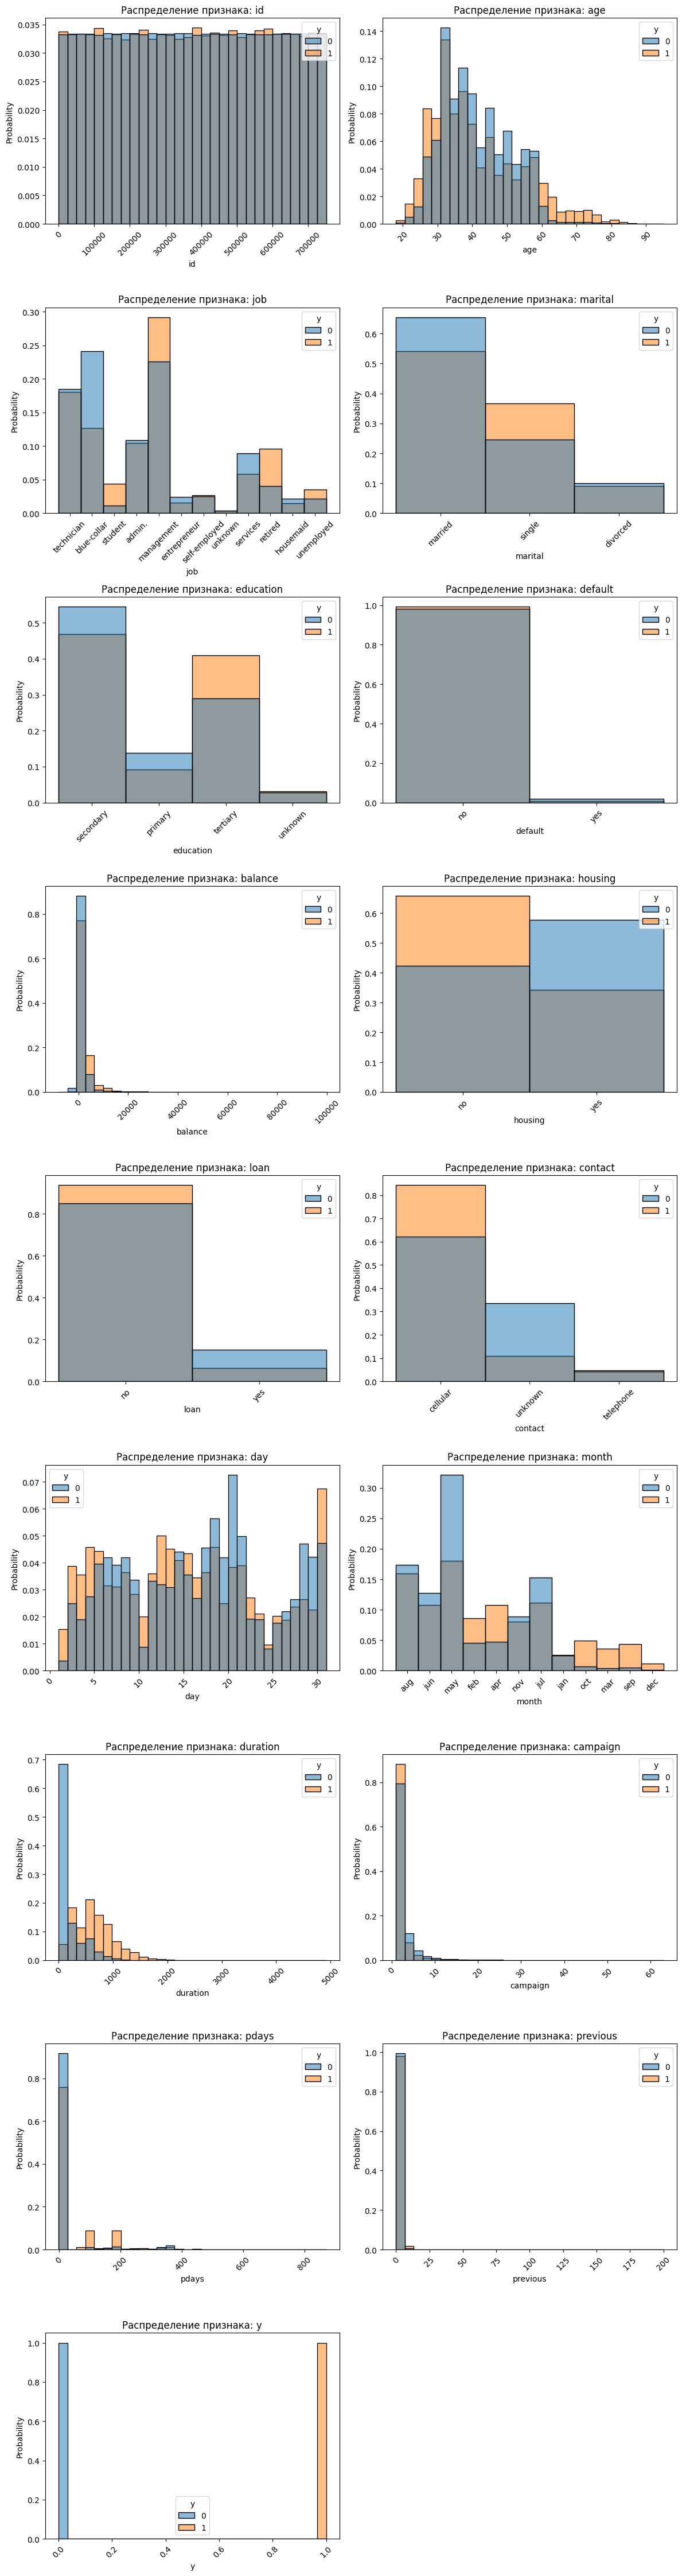

In [11]:
# Построение графиков распределения 
def plot_feature_target_distributions(df):
    num_features = df.shape[1]
    cols = 2 # Количество столбцов
    rows = math.ceil(num_features / cols)  # Количество строк
    plt.figure(figsize=(cols * 6, rows * 5))
    for i, column in enumerate(df.columns):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(data=df, x=column, hue='y',  stat="probability", common_norm=False, bins=30)
        plt.xticks(rotation=45)
        plt.title(f'Распределение признака: {column}')
    plt.tight_layout()
    plt.show()


plot_feature_target_distributions(df_train)

**Выводы о распределениях**

* числовые признаки распределены логнормально с длинным хвостом.
* при возрасте от 30 до 60 клиент вероятнее не заключит договор.
* blue-collar и services менее склонны делать вклады.
* students,management,retired,unemployed более склонны делать вклады.
* одинокие более часто делают вклады чем семейные.
* люди с высшим образованием намного больше делают вклады.
* с ростом баланса растет вероятность вклада.
* если есть жилищный кредит или займ человек скорее всего не сделает вклад.
* возможно неуказанный способ связи говорит о нежелании клиента сотрудничать, поэтому они с большей вероятностью отказываются.
* часть месяцев сильно выделяются повышенным уровнем согласия или отказов. 
* при очень маленьком duration очень маловероятно заключение договра. Что логично, если разговор не состоялся, видимо клиент не заинтересован.
* если предыдущая компания закончилась успехом, то новая скорее так же будет успешной.


**Выбросы**

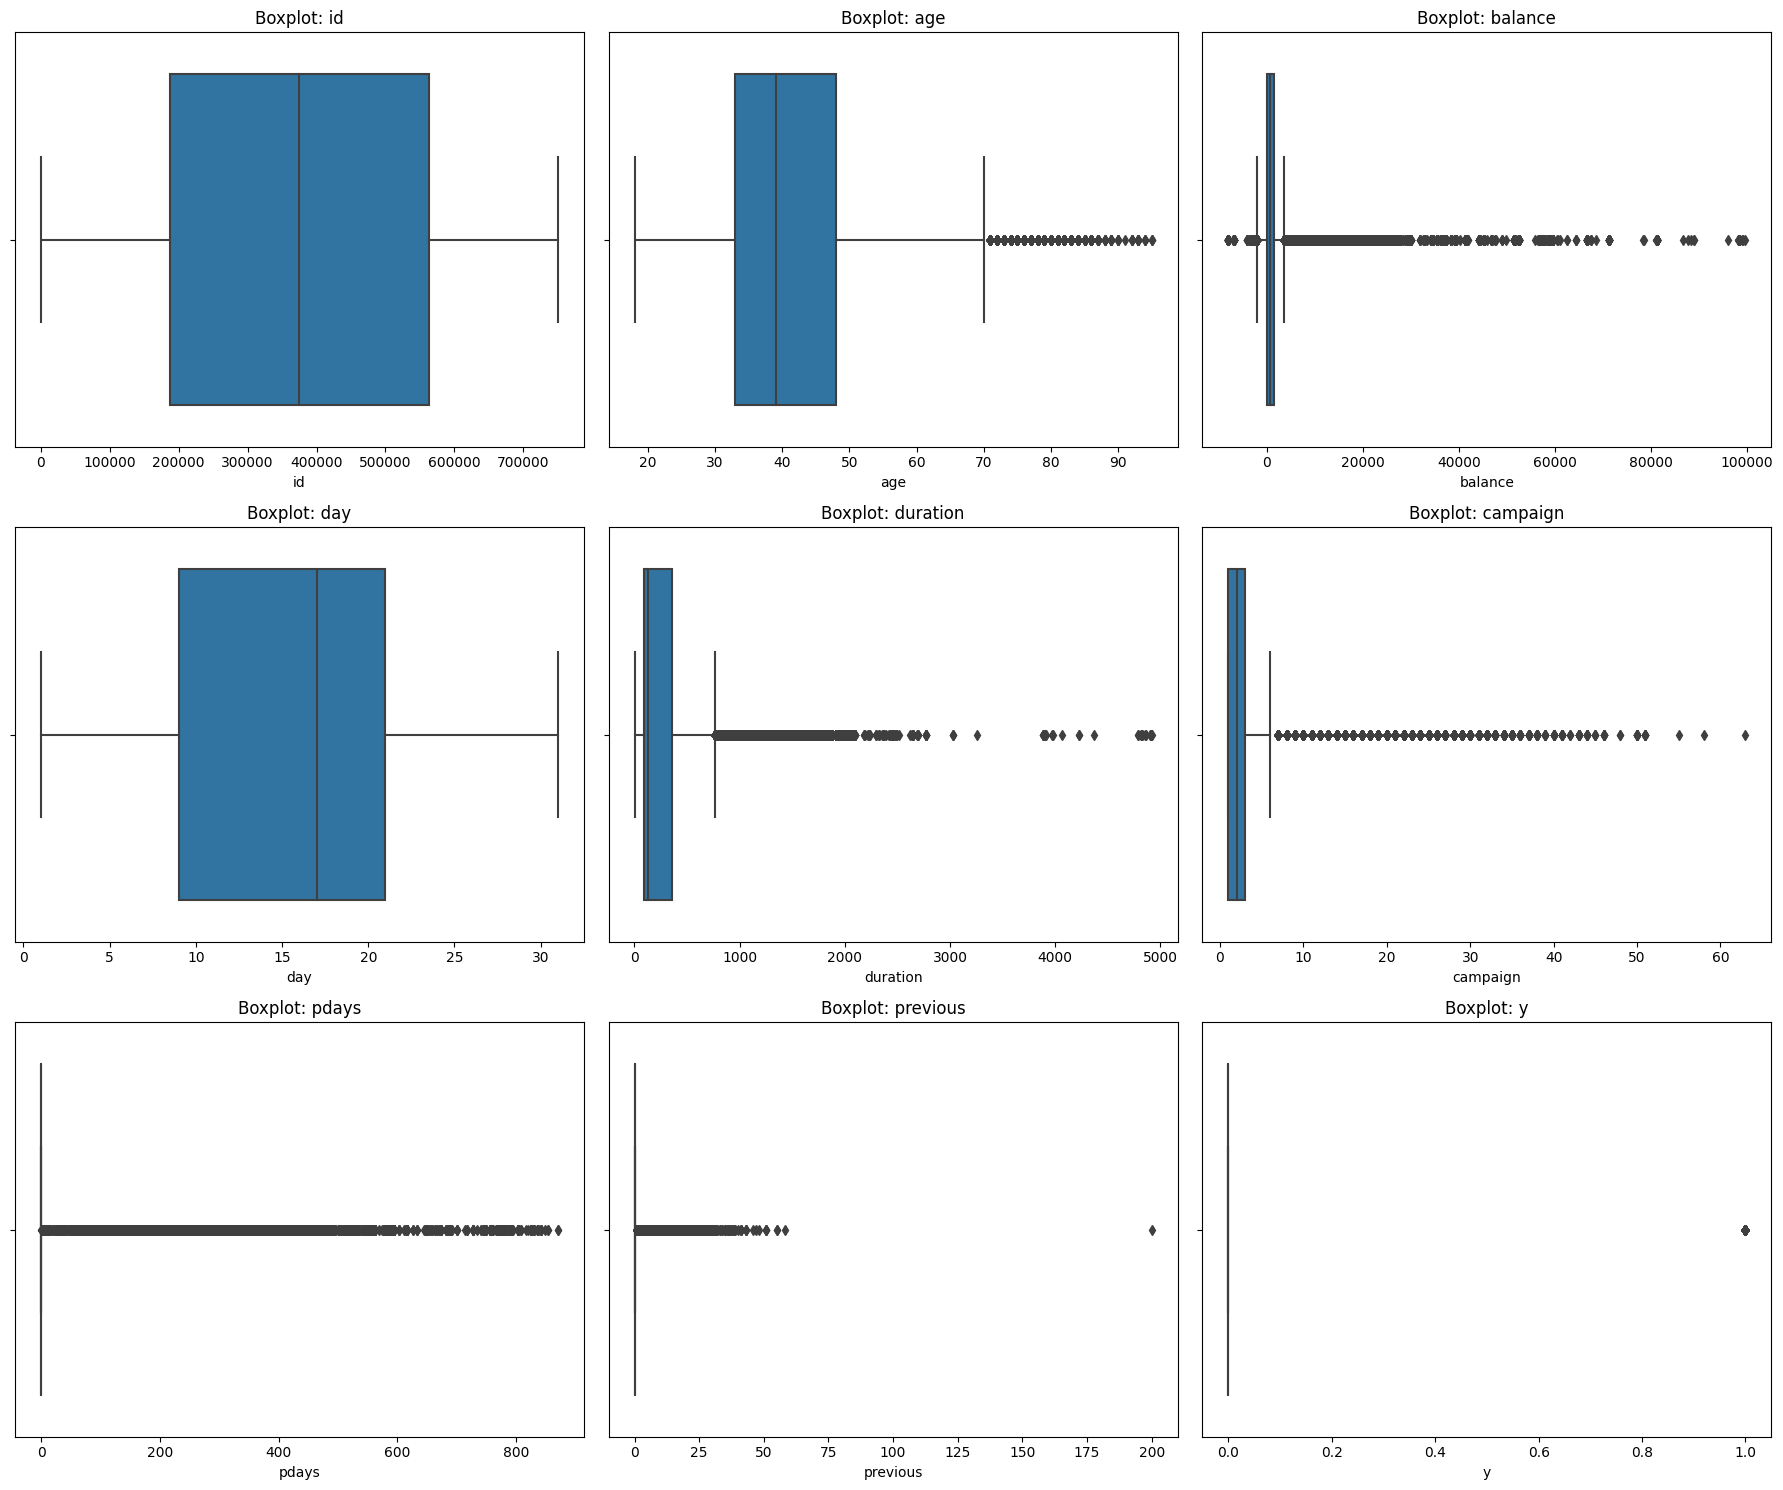

In [12]:
# Построение boxplot для каждого признака датафрейма
def plot_boxplots(df):
    cols = 3
    rows = (len(df.columns) + cols - 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))
    for i, col in enumerate(df.columns):
        plt.subplot(rows, cols, i + 1)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()


plot_boxplots(df_train.select_dtypes(include = 'number'))

In [13]:
#удаление выбросов
def handle_outliers_log(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    df_clean = df.copy()

    for col in numeric_cols:
        # Преобразование логарифмированием (с отрицательными значениями не трогаем)
        if (df_clean[col] <= 0).any():
            continue

        log_data = np.log(df_clean[col])

        Q1 = log_data.quantile(0.25)
        Q3 = log_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound_log = Q1 - 1.5 * IQR
        upper_bound_log = Q3 + 1.5 * IQR

        lower_bound = np.exp(lower_bound_log)
        upper_bound = np.exp(upper_bound_log)

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

In [14]:
#проверим количество оставшихся данных
shape_before = df_train.shape[0]
df_train = handle_outliers_log(df_train)
shape_after = df_train.shape[0]
print (f'Осталось {shape_after/shape_before*100}% наблюдений')

Осталось 92.86466666666666% наблюдений


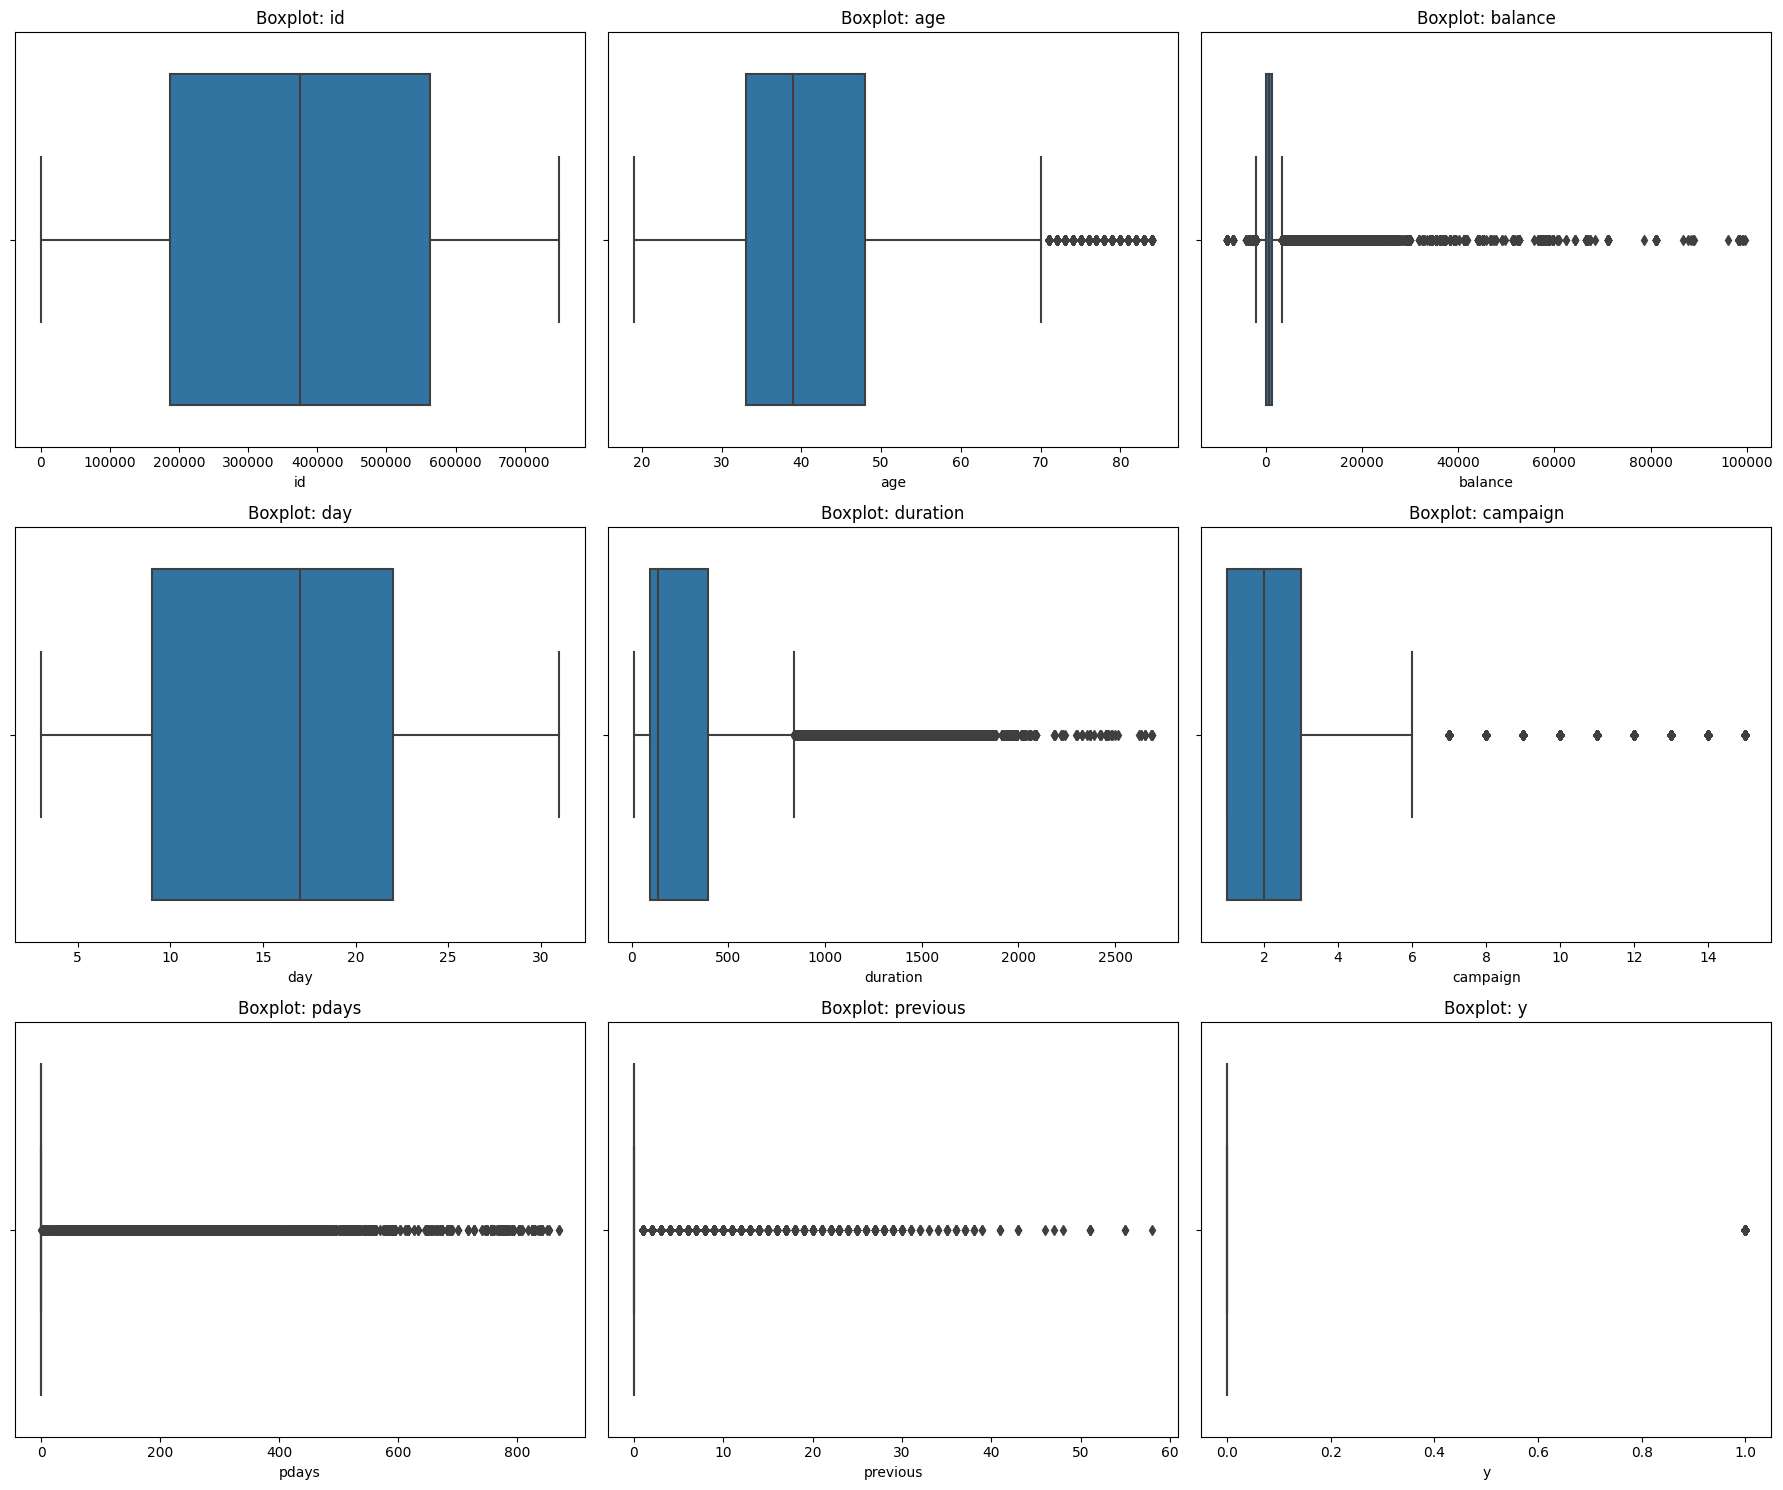

In [15]:
#еще раз взглянем на графики после удаления выбросов
plot_boxplots(df_train.select_dtypes(include = 'number'))

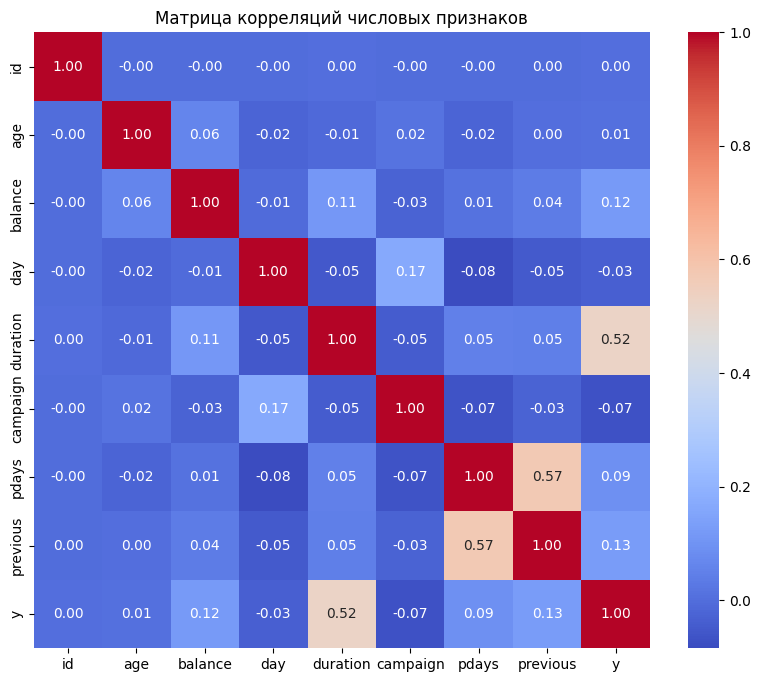

In [16]:
# Выделение только числовых столбцов
numeric_df = df_train.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()  # корреляция Пирсона по умолчанию
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)
plt.title("Матрица корреляций числовых признаков")
plt.show()

* duration и таргет (0.52) — длительность положительно связана с таргетом, возможно, длительность оказывает существенное влияние на результат.

* pdays и previous (0.57) — высокая корреляция указывает, что эти признаки тесно связаны, возможно, несут схожую информацию.

* Таргет имеет положительные, но не очень сильные корреляции, с balance (0.12), pdays (0.09), previous (0.13).

Поскольку у нас есть ограничение по памяти, приведем данные к типам меньших диапазонов, исходя из диапазонов значений признаков.

Делать это необязательно, но при оптимизации гиперпараметров я упирался в ограничение по памяти.

In [17]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', "uint16", "uint32", "uint64"]
for col in df_train.columns:
            col_type = df_train[col].dtypes
            
            if col_type in numerics:
                c_min = df_train[col].min()
                c_max = df_train[col].max()

                if "int" in str(col_type):
                    if c_min >= np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df_train[col] = df_train[col].astype(np.int8)
                    elif c_min >= np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df_train[col] = df_train[col].astype(np.int16)
                    elif c_min >= np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df_train[col] = df_train[col].astype(np.int32)
                    elif c_min >= np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df_train[col] = df_train[col].astype(np.int64)  
                else:
                    if c_min >= np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        df_train[col] = df_train[col].astype(np.float16)
                    if c_min >= np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df_train[col] = df_train[col].astype(np.float32)
                    else:
                        df_train[col] = df_train[col].astype(np.float64)

In [18]:
#делим на фичи и таргет. Признак id нам не нужен,т.к. не несет информации.
features = df_train.drop(['y','id'],axis = 1)
target = df_train['y']

In [19]:
#разделям выборки на тренировочную, валидационную и тестовую. 60:20:20 Учитываем дисбаланс классов
features_train,features_val_test,target_train,target_val_test = train_test_split(features,target,random_state = 42, test_size = 0.4,stratify=target)
features_val,features_test,target_val,target_test = train_test_split(features_val_test,target_val_test,random_state = 42, test_size = 0.5,stratify=target_val_test)

In [20]:
# у степени образованности есть порядковая зависимость. Кодируем в сответсвии с этим
education_categories = [ 'unknown', 'primary','secondary', 'tertiary']
ordinal_encoder = OrdinalEncoder(categories = [education_categories])
features_train['education_ordinal'] = ordinal_encoder.fit_transform(features_train[['education']])
features_val['education_ordinal'] = ordinal_encoder.transform(features_val[['education']])
features_test['education_ordinal'] = ordinal_encoder.transform(features_test[['education']])

In [21]:
#создадим дополнительные признаки
def feature_constuction(features):
    #метка положительности баланса
    features['balance_positive'] = (features['balance'] > 0).astype(int)

    #средняя продолжительность кампании
    features['avg_duration_per_campaign'] = features['duration'] / (features['campaign'] + 1)

    #метка что вообще не контактировали
    features['pdays_negative'] = (features['pdays'] == -1).astype(int)

    #соотношение контактов до и сейчас
    features['prev_to_campaign_ratio'] = features['previous'] / (features['campaign'] + 1)

    #обьединенный класс семейного положения и жилья
    features['marital_housing'] = features['marital'] + '_' + features['housing']
    
    #логарифм баланса
    features['balance_log'] = np.sign(features['balance']) * np.log1p(np.abs(features['balance']))
    
    #логарифм длительности
    features['duration_log'] = np.log1p(features['duration'])

    #логарифм количества контактов
    features['campaign_log'] = np.log1p(features['campaign'])

    return features

In [22]:
# Функция создания новых числовых признаков (произведение пар)
def add_numeric_combinations(features):
    numeric_cols = features.select_dtypes(include='number').columns
    new_cols = {}
    for c1, c2 in combinations(numeric_cols, 2):
        new_cols[f"{c1}_{c2}"] = features[c1] * features[c2]
    new_features = pd.DataFrame(new_cols)
    return pd.concat([features, new_features], axis=1)

In [23]:
# Функция создания новых категориальных признаков (конкатенация пар)
def add_categorical_combinations(features):
    categorical_cols = features.select_dtypes(exclude='number').columns
    features[categorical_cols] = features[categorical_cols].astype('category')
    new_features = pd.DataFrame()
    for cols in combinations(categorical_cols, 2):
        new_col_name = '_'.join(cols) + '_enc'
        new_features[new_col_name] = features[list(cols)].astype(str).agg('_'.join, axis=1).astype('category')
    return pd.concat([features, new_features], axis=1)

In [24]:
# Создание различных вариантов датасетов
def create_datasets(features_train, features_val):
    datasets = {}

    base_train = features_train.copy()
    base_val = features_val.copy()
    
    #Признаки созданные вручную добавляем в все варианты
    base_train = feature_constuction(base_train)
    base_val = feature_constuction(base_val)

    # Вариант 1: базовые признаки
    datasets['base'] = (base_train, base_val)

    # Вариант 2: с новыми числовыми признаками
    num_train = add_numeric_combinations(base_train.copy())
    num_val = add_numeric_combinations(base_val.copy())
    datasets['with_numeric'] = (num_train, num_val)

    # Вариант 3: с новыми категориальными признаками
    cat_train = add_categorical_combinations(base_train.copy())
    cat_val = add_categorical_combinations(base_val.copy())
    datasets['with_categorical'] = (cat_train, cat_val)

    # Вариант 4: с новыми числовыми и категориальными признаками
    all_train = add_numeric_combinations(base_train.copy())
    all_train = add_categorical_combinations(all_train)
    all_val = add_numeric_combinations(base_val.copy())
    all_val = add_categorical_combinations(all_val)
    datasets['with_all'] = (all_train, all_val)

    return datasets

In [25]:
def preprocess_and_pca(features_train, features_val, apply_pca=False):
    
    numeric_cols = features_train.select_dtypes(include='number').columns
    categorical_cols = features_train.select_dtypes(exclude='number').columns

    features_train[categorical_cols] = features_train[categorical_cols].astype('category')
    features_val[categorical_cols] = features_val[categorical_cols].astype('category')

    preprocessor = ColumnTransformer([
        ('num', RobustScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_cols)
    ])

    features_train_processed = preprocessor.fit_transform(features_train)
    features_val_processed = preprocessor.transform(features_val)

    if apply_pca:
        pca = PCA(n_components=0.95)  # 95% вариации
        features_train_processed = pca.fit_transform(features_train_processed)
        features_val_processed = pca.transform(features_val_processed)

    return features_train_processed, features_val_processed

In [26]:
# Инициализация моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Neural Network (MLP)': MLPClassifier(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'XGBClassifier':xgb.XGBClassifier()
}

In [27]:
results = []
datasets = create_datasets(features_train, features_val)

for data_name, (X_train, X_val) in datasets.items():
    for use_pca in [False, True]:
        print(f"Обучение на данных '{data_name}' с применением PCA = {use_pca}")
        X_train_final, X_val_final = preprocess_and_pca(X_train, X_val, apply_pca=use_pca)
        for model_name, model in models.items():
            print(f"  Обучение модели: {model_name}")
            model.fit(X_train_final, target_train)
            y_pred = model.predict(X_val_final)

            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_val_final)[:, 1]
                roc_auc = roc_auc_score(target_val, y_proba)
            else:
                roc_auc = None

            acc = accuracy_score(target_val, y_pred)
            prec = precision_score(target_val, y_pred, zero_division=0)
            rec = recall_score(target_val, y_pred, zero_division=0)
            f1 = f1_score(target_val, y_pred, zero_division=0)

            results.append({
                'Dataset': data_name,
                'PCA Applied': use_pca,
                'Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1 Score': f1,
                'ROC AUC': roc_auc
            })

Обучение на данных 'base' с применением PCA = False
  Обучение модели: Logistic Regression
  Обучение модели: Decision Tree
  Обучение модели: Bernoulli Naive Bayes
  Обучение модели: Neural Network (MLP)
  Обучение модели: Random Forest
  Обучение модели: XGBClassifier
Обучение на данных 'base' с применением PCA = True
  Обучение модели: Logistic Regression
  Обучение модели: Decision Tree
  Обучение модели: Bernoulli Naive Bayes
  Обучение модели: Neural Network (MLP)
  Обучение модели: Random Forest
  Обучение модели: XGBClassifier
Обучение на данных 'with_numeric' с применением PCA = False
  Обучение модели: Logistic Regression
  Обучение модели: Decision Tree
  Обучение модели: Bernoulli Naive Bayes
  Обучение модели: Neural Network (MLP)
  Обучение модели: Random Forest
  Обучение модели: XGBClassifier
Обучение на данных 'with_numeric' с применением PCA = True
  Обучение модели: Logistic Regression
  Обучение модели: Decision Tree
  Обучение модели: Bernoulli Naive Bayes
  Обучен

In [28]:
# ищем лучшие результаты по ROC AUC
df_results = pd.DataFrame(results)
df_results.sort_values(by = 'ROC AUC',ascending = False)

,Dataset,PCA Applied,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,base,False,XGBClassifier,0.933172,0.758287,0.665943,0.709121,0.964548
17,with_numeric,False,XGBClassifier,0.933021,0.757327,0.665767,0.708601,0.964384
41,with_all,False,XGBClassifier,0.932281,0.754893,0.661013,0.704841,0.963858
29,with_categorical,False,XGBClassifier,0.932281,0.755509,0.659957,0.704508,0.963830
4,base,False,Random Forest,0.929833,0.746188,0.646165,0.692584,0.959515
40,with_all,False,Random Forest,0.929848,0.746423,0.645930,0.692550,0.959145
3,base,False,Neural Network (MLP),0.929259,0.732992,0.663302,0.696408,0.959014
16,with_numeric,False,Random Forest,0.927105,0.741800,0.619813,0.675342,0.957815
15,with_numeric,False,Neural Network (MLP),0.926122,0.726443,0.635249,0.677792,0.955181
28,with_categorical,False,Random Forest,0.924449,0.727718,0.610951,0.664242,0.951655


# Выводы
Лучшие результаты у градиентного бустинга, независимо от созданных новых признаков, без PCA.

За градиентным бустингом идут случайный лес и нейронная сеть.

Модели на данных без PCA показали себя лучше.


Для дальнейшей работы попробуем оптимизировать гиперпараметры для градиентного бустинга на различных комбинациях данных и сравним их.

In [29]:
neg_count = sum(target_train == 0)
pos_count = sum(target_train == 1)
scale_pos_weight = neg_count / pos_count

In [42]:
X_train, X_val = datasets['base']
X_train_final, X_val_final = preprocess_and_pca(X_train, X_val, apply_pca=False)

In [45]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.01, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 15),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_final, target_train)

    y_pred_proba = model.predict_proba(X_val_final)[:, 1]
    roc_auc = roc_auc_score(target_val, y_pred_proba)

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return roc_auc


In [46]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Лучшие параметры:", study.best_params)
print("Лучший ROC-AUC:", study.best_value)

[I 2025-10-30 07:30:17,027] A new study created in memory with name: no-name-6cebc4b0-4d8a-44b4-829d-b821c1b3e16a
[I 2025-10-30 07:30:37,123] Trial 0 finished with value: 0.9557187923914577 and parameters: {'learning_rate': 1.2376367806852285e-05, 'max_depth': 17, 'n_estimators': 200, 'subsample': 0.8138683499782499, 'colsample_bytree': 0.5098077549595147, 'gamma': 1.5193924904028133, 'min_child_weight': 11, 'reg_alpha': 14.490663788213208, 'reg_lambda': 0.648765300190952}. Best is trial 0 with value: 0.9557187923914577.
[I 2025-10-30 07:31:10,536] Trial 1 finished with value: 0.9533945603107294 and parameters: {'learning_rate': 0.0004095986269721689, 'max_depth': 11, 'n_estimators': 450, 'subsample': 0.22038316637097538, 'colsample_bytree': 0.6491557433994556, 'gamma': 4.327844403445543, 'min_child_weight': 14, 'reg_alpha': 8.089375764943485, 'reg_lambda': 5.550988861410566e-05}. Best is trial 0 with value: 0.9557187923914577.
[I 2025-10-30 07:31:40,956] Trial 2 finished with value: 0

Лучшие параметры: {'learning_rate': 0.029518277057525112, 'max_depth': 30, 'n_estimators': 900, 'subsample': 0.7072399141486703, 'colsample_bytree': 0.6739970866282674, 'gamma': 3.0892513055583004, 'min_child_weight': 6, 'reg_alpha': 9.889787765042055, 'reg_lambda': 0.04571330378888064}
Лучший ROC-AUC: 0.9663782010761335


In [47]:
optuna.importance.get_param_importances(study)

{'max_depth': 0.4194191158284149,
 'learning_rate': 0.27412792044660544,
 'colsample_bytree': 0.1597357780504166,
 'min_child_weight': 0.06787294733343316,
 'subsample': 0.060629987908743944,
 'reg_lambda': 0.0069382374860451285,
 'gamma': 0.005601396883668337,
 'n_estimators': 0.0054196819512103,
 'reg_alpha': 0.00025493411146217495}

In [48]:
best_xgb = xgb.XGBClassifier(**study.best_params)

In [53]:
features_train_val = pd.concat([features_train, features_val], ignore_index=True)
target_train_val = pd.concat([target_train, target_val], ignore_index=True)

features_train_final, features_test_final = preprocess_and_pca(features_train_val, features_test, apply_pca=False)

best_xgb.fit(features_train_final,target_train_val )
xgb_y_pred_proba = best_xgb.predict_proba(features_test_final)[:, 1]

In [54]:
xgb_roc_auc = roc_auc_score(target_test, xgb_y_pred_proba)
print(f'ROC AUC: {xgb_roc_auc:}')

ROC AUC: 0.9668579987628395


In [58]:
#features_test = df_test.drop(['id'],axis=1)
#features_test['education_ordinal'] = ordinal_encoder.transform(features_test[['education']])
#features_test = feature_constuction(features_test)
#
#features_train_final, features_test_final = preprocess_and_pca(features_train_val, features_test, apply_pca=False)
#
#test_ids = df_test["id"]
#xgb_y_pred_proba = best_xgb.predict_proba(features_test_final)[:, 1]
#submission = pd.DataFrame({"id": test_ids, "y": xgb_y_pred_proba})
#submission.to_csv("/kaggle/working/submission.csv", index=False)